In [25]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [26]:
order = pd.read_csv('../data/order_clean.csv')
products = pd.read_csv('../data/products_clean.csv')
marketing = pd.read_csv('../data/marketing_clean.csv')


order['order_date'] = pd.to_datetime(order['order_date'])
marketing['month_dt'] = pd.to_datetime(marketing['month'])

print(f"Order    : {order.shape}")
print(f"Products : {products.shape}")
print(f"Marketing: {marketing.shape}")

Order    : (1997, 26)
Products : (207, 9)
Marketing: (144, 11)


In [27]:
category=order.groupby('primary_category').agg(
    total_orders=('order_id','count'),
    total_revenue=('gross_revenue','sum'),
    total_discount=('discount_amount','sum'),
    total_shipping=('shipping_cost','sum'),
    total_product_cost=('product_cost','sum'),
    total_platform_fee=('refund_amount','sum'),
    total_refund=('refund_amount','sum'),
    total_profit=('profit','sum'),
    avg_profit_margin=('profit_margin_%','mean'),
    return_rate=('returned_binary','mean')
).reset_index()


category['return_rate_%']=(category['return_rate']*100).round(2)

category['total_profit_margin_%']=(category['total_profit']/category['total_revenue']*100).round(2)

category=category.sort_values('total_profit_margin_%',ascending=True)
print(category[['primary_category', 'total_orders', 'total_revenue',
 'total_profit', 'total_profit_margin_%',
 'return_rate_%']].to_string(index=False))

primary_category  total_orders  total_revenue  total_profit  total_profit_margin_%  return_rate_%
           Books           238       22360.48       2236.04                  10.00           8.40
          Beauty           204       20672.65       3104.48                  15.02           5.88
        Clothing           293       37515.60       6272.48                  16.72           8.19
          Sports           292       37453.25       7596.63                  20.28           7.19
 Food & Beverage           247       36878.52       7591.77                  20.59           5.67
  Home & Kitchen           200       30879.43       6688.57                  21.66           6.00
            Toys           256       39011.88       8756.12                  22.44           7.03
     Electronics           267       52876.49      13973.46                  26.43           8.61


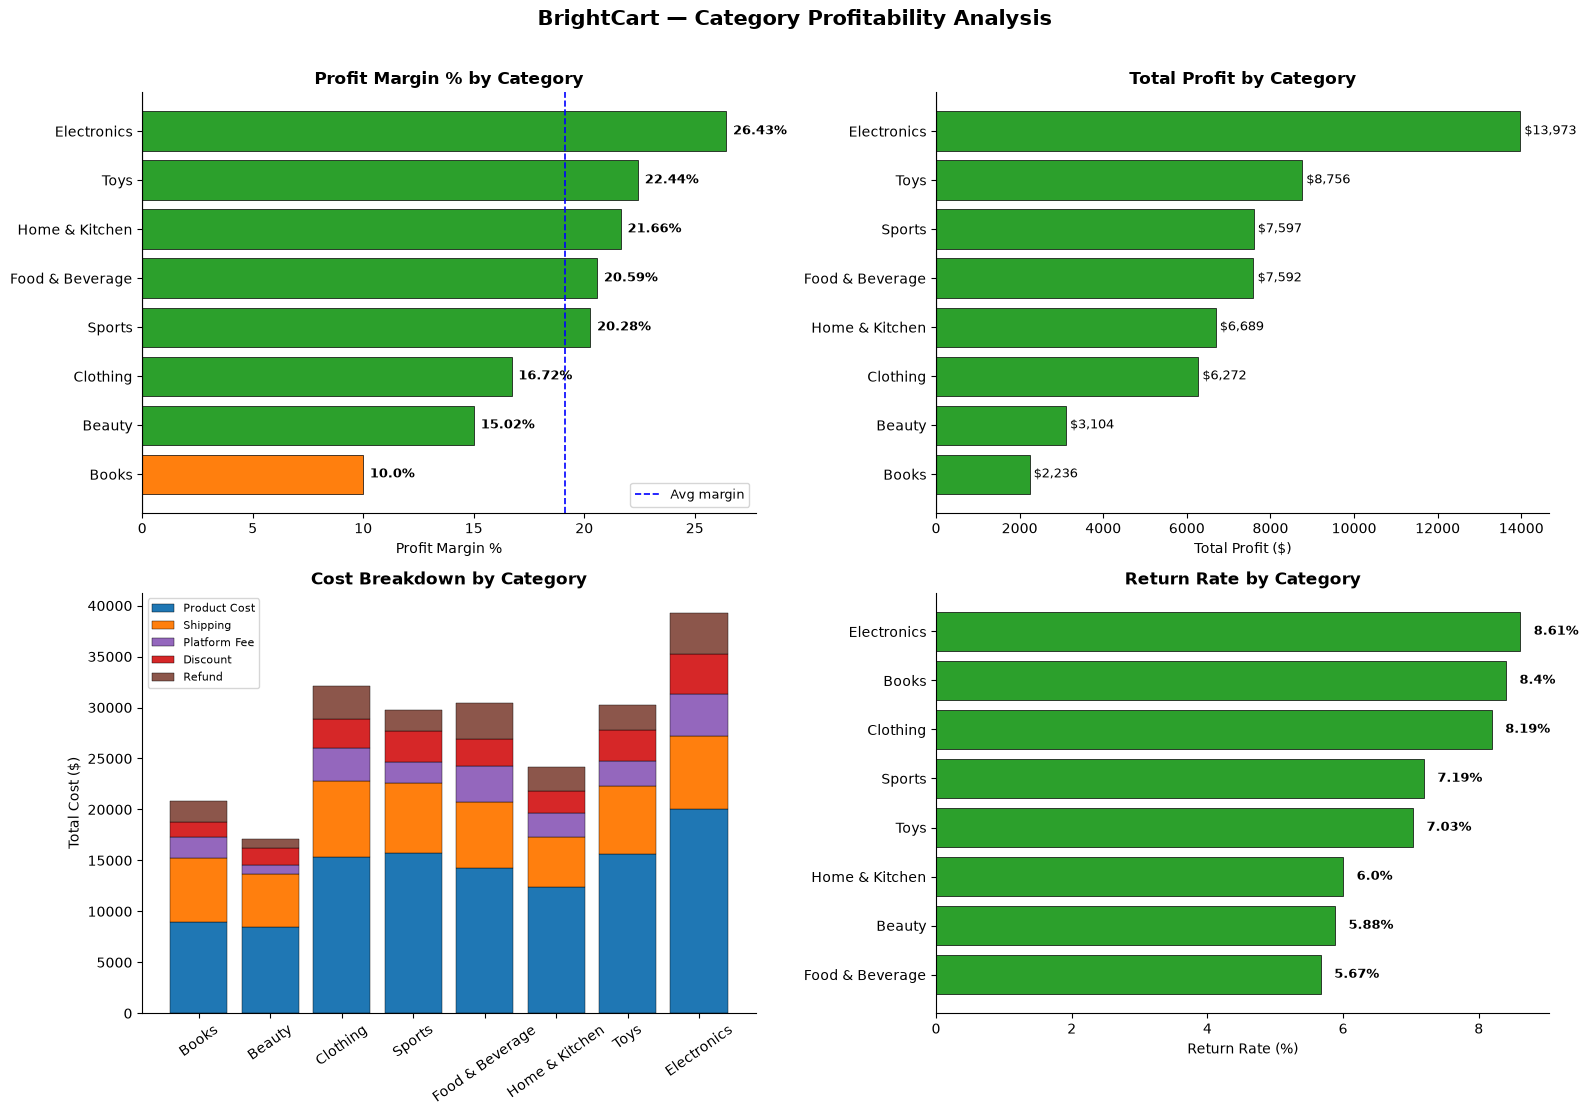

In [28]:
fig,axes=plt.subplots(2,2,figsize=(16,11))
fig.suptitle('BrightCart — Category Profitability Analysis',
      fontsize=15,fontweight='bold',y=1.01

)
cat_sorted=category.sort_values('total_profit_margin_%',ascending=True)
colors = ['#d62728' if x < 0 else '#ff7f0e' if x < 15
          else '#2ca02c' for x in cat_sorted['total_profit_margin_%']]

bars=axes[0,0].barh(
    cat_sorted['primary_category'],
    cat_sorted['total_profit_margin_%'],
    color=colors,edgecolor='black',linewidth=0.5
)

axes[0,0].axvline(0,color='black',linewidth=0.8)
axes[0,0].axvline(cat_sorted['total_profit_margin_%'].mean(),
color='blue',linestyle='--',linewidth=1.2,label='Avg margin'
)
for bar, val in zip(bars, cat_sorted['total_profit_margin_%']):
    axes[0,0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=9, fontweight='bold')

axes[0,0].set_title('Profit Margin % by Category', fontweight='bold')
axes[0,0].set_xlabel('Profit Margin %')
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)



cat_profit = category.sort_values('total_profit', ascending=True)
colors2 = ['#d62728' if x < 0 else '#2ca02c'
           for x in cat_profit['total_profit']]

bars2 = axes[0,1].barh(cat_profit['primary_category'],
                        cat_profit['total_profit'],
                        color=colors2, edgecolor='black', linewidth=0.5)
axes[0,1].axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars2, cat_profit['total_profit']):
    axes[0,1].text(val + 100, bar.get_y() + bar.get_height()/2,
                   f'${val:,.0f}', va='center', fontsize=9)
axes[0,1].set_title('Total Profit by Category', fontweight='bold')
axes[0,1].set_xlabel('Total Profit ($)')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)


cat_cost = category.set_index('primary_category')
cost_cols = ['total_product_cost', 'total_shipping',
             'total_platform_fee', 'total_discount', 'total_refund']
cost_labels = ['Product Cost', 'Shipping',
               'Platform Fee', 'Discount', 'Refund']
cost_colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#d62728', '#8c564b']

bottom = pd.Series([0] * len(cat_cost), index=cat_cost.index)
for col, label, color in zip(cost_cols, cost_labels, cost_colors):
    axes[1,0].bar(cat_cost.index, cat_cost[col],
                  bottom=bottom, label=label,
                  color=color, edgecolor='black', linewidth=0.3)
    bottom += cat_cost[col]

axes[1,0].set_title('Cost Breakdown by Category', fontweight='bold')
axes[1,0].set_ylabel('Total Cost ($)')
axes[1,0].tick_params(axis='x', rotation=35)
axes[1,0].legend(fontsize=8)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)



# ── Panel 4: Return Rate by Category
cat_return = category.sort_values('return_rate_%', ascending=True)
colors3 = ['#d62728' if x > 15 else '#ff7f0e' if x > 10
           else '#2ca02c' for x in cat_return['return_rate_%']]

bars3 = axes[1,1].barh(cat_return['primary_category'],
                        cat_return['return_rate_%'],
                        color=colors3, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, cat_return['return_rate_%']):
    axes[1,1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=9, fontweight='bold')
axes[1,1].set_title('Return Rate by Category', fontweight='bold')
axes[1,1].set_xlabel('Return Rate (%)')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart1_category_profitability.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 1 — Category Profitability Insight

**Profit Margin Ranking:**
| Category | Margin | Status |
|---|---|---|
| Electronics | 26.43% | 🟢 Best performer |
| Toys | 22.44% | 🟢 Strong |
| Home & Kitchen | 21.66% | 🟢 Strong |
| Food & Beverage | 20.59% | 🟢 Strong |
| Sports | 20.28% | 🟢 Strong |
| Clothing | 16.72% | 🟠 Below average |
| Beauty | 15.02% | 🟠 Below average |
| Books | 10.00% | 🔴 Weakest — needs review |

**Key Findings:**
- Electronics generates 26.43% margin and $13,973 total profit —
  the single most valuable category despite high product costs
- Books has the lowest margin at 10% — driven by high shipping
  costs relative to low average selling price
- Beauty has the lowest return rate (5.88%) but still underperforms
  on margin — discount strategy is likely eroding profitability
- No category is loss-making at aggregate level — but 563 individual
  orders across all categories are unprofitable (28.15%)
- Average margin across all categories: ~19%

**What's driving the difference:**
- High margin: High selling price relative to product cost (Electronics, Toys)
- Low margin: High shipping cost relative to revenue (Books)
  or high discount usage (Beauty, Clothing)

**Recommendation:**
- Double down on Electronics and Toys — highest margin + high volume
- Review Books pricing strategy — increase selling price or
  introduce free shipping threshold to improve margin
- Audit Beauty discount policy — returns are low so the
  product is good, discounts are the problem

In [29]:
# Channel Analysis
channel=order.groupby('channel').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('gross_revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_order_value=('gross_revenue', 'mean'),
    avg_profit_per_order=('profit', 'mean'),
    avg_profit_margin=('profit_margin_%', 'mean'),
    total_platform_fee=('platform_fee', 'sum'),
    total_discount=('discount_amount', 'sum'),
    return_rate=('returned_binary', 'mean')
    
).reset_index()


channel['return_rate_%']=(channel['return_rate']*100).round(2)
channel['profit_margin_%']=(
    channel['total_profit']/channel['total_revenue']*100
).round(2)
channel['avg_platform_fee_per_order']=(
    channel['total_platform_fee']/channel['total_orders']
).round(2)

channel=channel.sort_values('profit_margin_%',ascending=False)
print(channel[['channel', 'total_orders', 'total_revenue',
'total_profit', 'profit_margin_%',
'avg_profit_per_order', 'avg_platform_fee_per_order',
'return_rate_%']].to_string(index=False))

        channel  total_orders  total_revenue  total_profit  profit_margin_%  avg_profit_per_order  avg_platform_fee_per_order  return_rate_%
     Mobile App           588       82656.82      21363.17            25.85             36.331922                        0.00           7.31
        Website           793      110913.43      25034.31            22.57             31.569117                        0.00           7.06
Social Commerce           197       26446.61       3370.54            12.74             17.109340                        9.87           9.14
    Marketplace           419       57631.44       6451.53            11.19             15.397446                       18.97           6.44


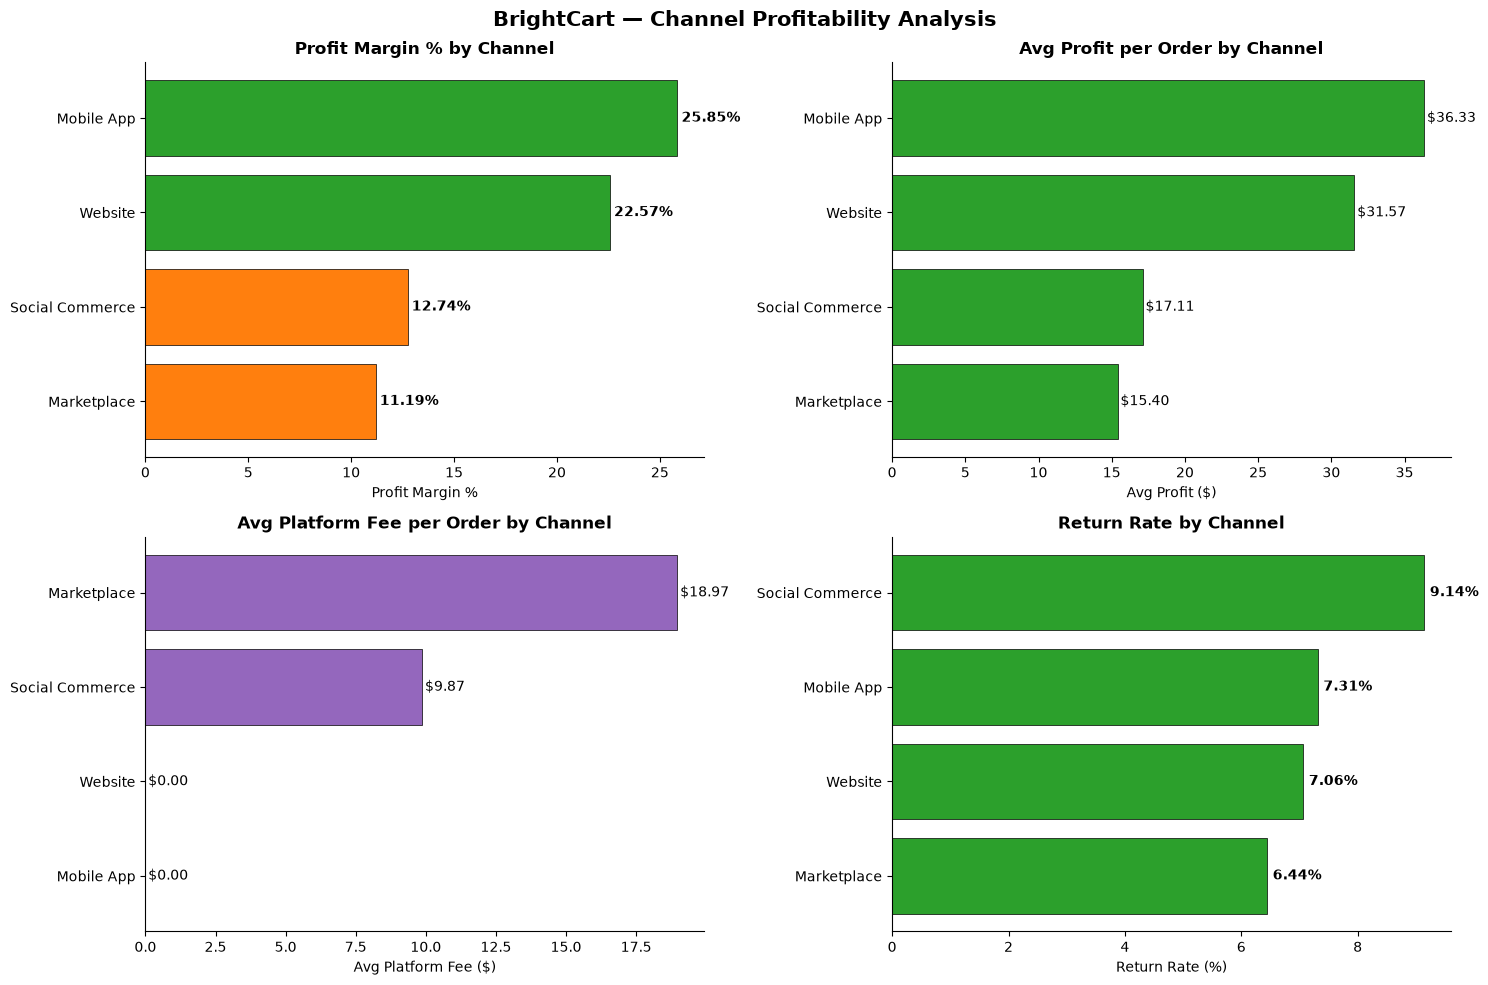

In [30]:
fig,axes=plt.subplots(2,2,figsize=(15,10))

fig.suptitle('BrightCart — Channel Profitability Analysis',
             fontsize=15, fontweight='bold')

ch_asc=channel.sort_values('profit_margin_%',ascending=True) 
#Profit Margin Rate by Channels
colors=['#d62728' if x < 0 else '#ff7f0e' if x < 15 else '#2ca02c' for x in ch_asc['profit_margin_%']]

bars = axes[0,0].barh(ch_asc['channel'], ch_asc['profit_margin_%'],
                       color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, ch_asc['profit_margin_%']):
    axes[0,0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Profit Margin % by Channel', fontweight='bold')
axes[0,0].set_xlabel('Profit Margin %')
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

#Avg Profit per Order By Columns

ch_profit=channel.sort_values('avg_profit_per_order',ascending=True)
colors2 = ['#d62728' if x < 0 else '#ff7f0e' if x < 15
           else '#2ca02c' for x in ch_profit['avg_profit_per_order']]

bars2 = axes[0,1].barh(ch_profit['channel'],
                        ch_profit['avg_profit_per_order'],
                        color=colors2, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, ch_profit['avg_profit_per_order']):
    axes[0,1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                   f'${val:.2f}', va='center', fontsize=10)
axes[0,1].set_title('Avg Profit per Order by Channel', fontweight='bold')
axes[0,1].set_xlabel('Avg Profit ($)')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)


#Avg Platform Fee Per Order
ch_fee = channel.sort_values('avg_platform_fee_per_order', ascending=True)

bars3 = axes[1,0].barh(ch_fee['channel'],
                        ch_fee['avg_platform_fee_per_order'],
                        color='#9467bd', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, ch_fee['avg_platform_fee_per_order']):
    axes[1,0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'${val:.2f}', va='center', fontsize=10)
axes[1,0].set_title('Avg Platform Fee per Order by Channel',
                     fontweight='bold')
axes[1,0].set_xlabel('Avg Platform Fee ($)')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
#Return rate by Channel
ch_ret = channel.sort_values('return_rate_%', ascending=True)
colors4 = ['#d62728' if x > 15 else '#ff7f0e' if x > 10
           else '#2ca02c' for x in ch_ret['return_rate_%']]

bars4 = axes[1,1].barh(ch_ret['channel'], ch_ret['return_rate_%'],
                        color=colors4, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars4, ch_ret['return_rate_%']):
    axes[1,1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=10, fontweight='bold')
axes[1,1].set_title('Return Rate by Channel', fontweight='bold')
axes[1,1].set_xlabel('Return Rate (%)')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)



plt.tight_layout()
plt.savefig('../reports/chart2_channel_profitability.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 2 — Channel Profitability Insight

| Channel | Margin % | Avg Profit/Order | Platform Fee | Return Rate |
|---|---|---|---|---|
| Mobile App | 25.85% | $36.33 | $0.00 | 7.31% |
| Website | 22.57% | $31.57 | $0.00 | 7.06% |
| Social Commerce | 12.74% | $17.11 | $9.87 | 9.14% |
| Marketplace | 11.19% | $15.40 | $18.97 | 6.44% |

**Key Findings:**
- Mobile App is BrightCart's most profitable channel —
  zero platform fees + highest avg profit per order ($36.33)
- Marketplace platform fee of $18.97/order is the single
  biggest channel cost driver — cutting margin by ~55%
  compared to owned channels
- Social Commerce suffers from the highest return rate (9.14%)
  AND a $9.87 platform fee — double margin pressure
- Website and Mobile App (owned channels) outperform third-party
  channels by 2x on profit margin

**Recommendation:**
- Invest in Mobile App user acquisition — highest ROI channel
- Renegotiate Marketplace platform fees or reduce SKU count
  listed there to only high-margin Electronics and Toys
- Audit Social Commerce product listings — high returns suggest
  product presentation or expectation mismatch

In [31]:
#Overall return stats 
total_returned = order['returned_binary'].sum()
total_orders = len(order)
total_refund = order['refund_amount'].sum()
total_revenue = order['gross_revenue'].sum()

print("=== OVERALL RETURN SUMMARY ===")
print(f"Total Orders      : {total_orders}")
print(f"Total Returned    : {total_returned}")
print(f"Overall Return Rate: {total_returned/total_orders*100:.2f}%")
print(f"Total Refund Amount: ${total_refund:,.2f}")
print(f"Refund as % of Revenue: {total_refund/total_revenue*100:.2f}%")

=== OVERALL RETURN SUMMARY ===
Total Orders      : 1997
Total Returned    : 144
Overall Return Rate: 7.21%
Total Refund Amount: $20,582.45
Refund as % of Revenue: 7.41%


In [32]:
cat_return = order.groupby('primary_category').agg(
    total_orders=('order_id', 'count'),
    total_returned=('returned_binary', 'sum'),
    total_refund=('refund_amount', 'sum'),
    avg_refund=('refund_amount', 'mean')
).reset_index()
cat_return['return_rate_%'] = (
    cat_return['total_returned'] / cat_return['total_orders'] * 100
).round(2)
cat_return['revenue_lost_%'] = (
    cat_return['total_refund'] /
    order.groupby('primary_category')['gross_revenue'].sum().values * 100
).round(2)
cat_return = cat_return.sort_values('return_rate_%', ascending=False)


print(cat_return[['primary_category', 'total_orders', 'total_returned',
                   'return_rate_%', 'total_refund',
                   'revenue_lost_%']].to_string(index=False))

primary_category  total_orders  total_returned  return_rate_%  total_refund  revenue_lost_%
     Electronics           267              23           8.61       4078.27            7.71
           Books           238              20           8.40       2106.36            9.42
        Clothing           293              24           8.19       3209.21            8.55
          Sports           292              21           7.19       2008.44            5.36
            Toys           256              18           7.03       2469.81            6.33
  Home & Kitchen           200              12           6.00       2340.10            7.58
          Beauty           204              12           5.88        865.70            4.19
 Food & Beverage           247              14           5.67       3504.56            9.50


In [33]:
# ── Return rate by channel ──
ch_return = order.groupby('channel').agg(
    total_orders=('order_id', 'count'),
    total_returned=('returned_binary', 'sum'),
    total_refund=('refund_amount', 'sum')
).reset_index()
ch_return['return_rate_%'] = (
    ch_return['total_returned'] / ch_return['total_orders'] * 100
).round(2)
ch_return['revenue_lost_%'] = (
    ch_return['total_refund'] /
    order.groupby('channel')['gross_revenue'].sum().values * 100
).round(2)
ch_return = ch_return.sort_values('return_rate_%', ascending=False)

print("\n=== RETURN RATE BY CHANNEL ===")
print(ch_return[['channel', 'total_orders', 'total_returned',
                  'return_rate_%', 'total_refund',
                  'revenue_lost_%']].to_string(index=False))


=== RETURN RATE BY CHANNEL ===
        channel  total_orders  total_returned  return_rate_%  total_refund  revenue_lost_%
Social Commerce           197              18           9.14       2381.65            9.01
     Mobile App           588              43           7.31       5324.17            6.44
        Website           793              56           7.06       9383.68            8.46
    Marketplace           419              27           6.44       3492.95            6.06


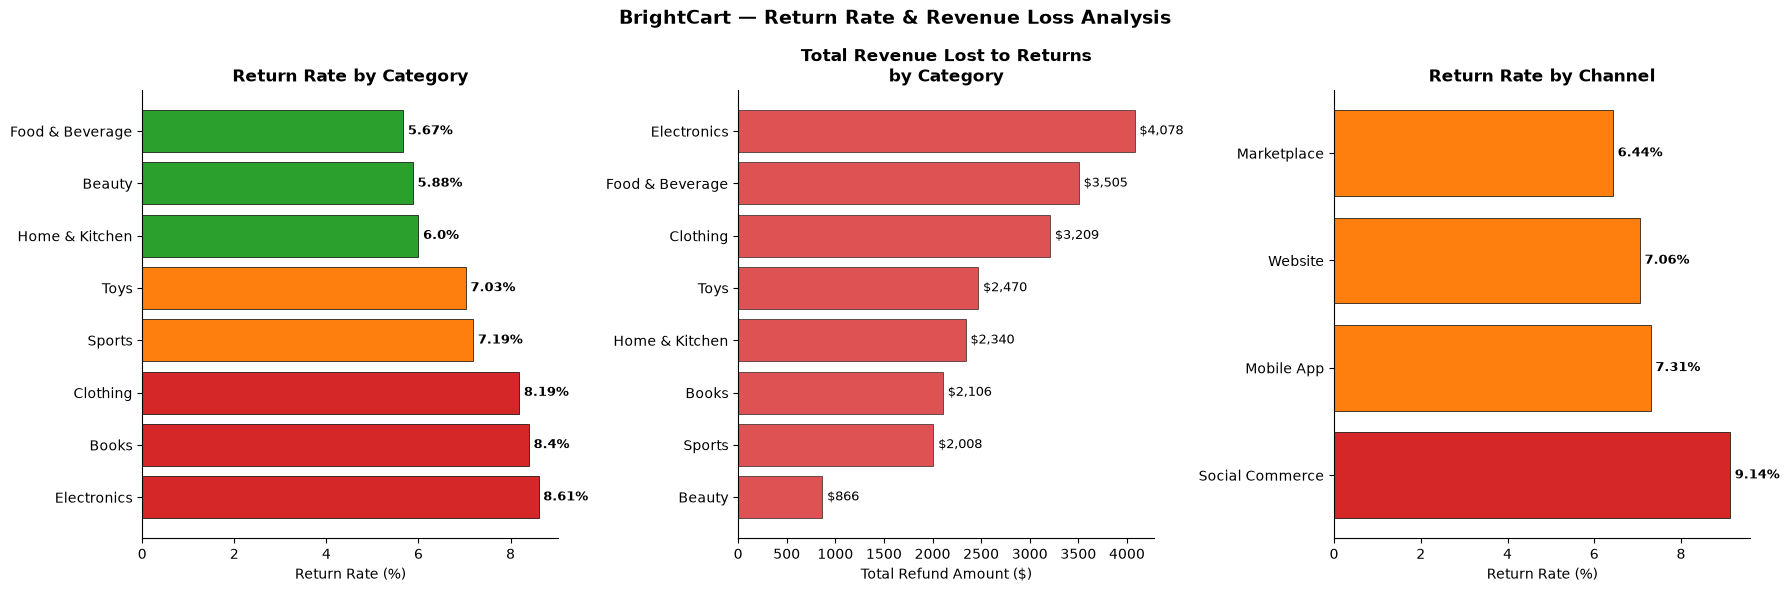

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('BrightCart — Return Rate & Revenue Loss Analysis',fontsize=14, fontweight='bold')

#Return rate by Category
colors = ['#d62728' if x > 8 else '#ff7f0e' if x > 6
          else '#2ca02c' for x in cat_return['return_rate_%']]

bars = axes[0].barh(cat_return['primary_category'],
                     cat_return['return_rate_%'],
                     color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cat_return['return_rate_%']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Return Rate by Category', fontweight='bold')
axes[0].set_xlabel('Return Rate (%)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

#  Revenue Lost to Returns by Category 
cat_rev = cat_return.sort_values('total_refund', ascending=True)
bars2 = axes[1].barh(cat_rev['primary_category'],
                      cat_rev['total_refund'],
                      color='#d62728', edgecolor='black',
                      linewidth=0.5, alpha=0.8)
for bar, val in zip(bars2, cat_rev['total_refund']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)
axes[1].set_title('Total Revenue Lost to Returns\nby Category',
                   fontweight='bold')
axes[1].set_xlabel('Total Refund Amount ($)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
#Return Rate by Channel
colors3 = ['#d62728' if x > 8 else '#ff7f0e' if x > 6
           else '#2ca02c' for x in ch_return['return_rate_%']]

bars3 = axes[2].barh(ch_return['channel'],
                      ch_return['return_rate_%'],
                      color=colors3, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, ch_return['return_rate_%']):
    axes[2].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9, fontweight='bold')
axes[2].set_title('Return Rate by Channel', fontweight='bold')
axes[2].set_xlabel('Return Rate (%)')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart3_returns_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 3 — Return Rate & Revenue Loss Insight

**Overall Return Impact:**
- Total revenue lost to returns: ~$20,582 across all categories
- Returns represent a significant margin erosion across all channels

**By Category:**
| Category | Return Rate | Revenue Lost |
|---|---|---|
| Electronics | 8.61% 🔴 | $4,078 — highest loss |
| Books | 8.40% 🔴 | $2,106 |
| Clothing | 8.19% 🔴 | $3,209 |
| Food & Beverage | 5.67% 🟢 | $3,505 — low rate, high loss |
| Beauty | 5.88% 🟢 | $866 — healthiest category |

**By Channel:**
| Channel | Return Rate |
|---|---|
| Social Commerce | 9.14% 🔴 — highest |
| Marketplace | 6.44% 🟢 — lowest |

**Key Findings:**
- Electronics loses $4,078 to returns despite being the top 
  profit category — returns are the biggest threat to its dominance
- Food & Beverage has low return rate but high refund value —
  high-ticket food orders when returned cause outsized revenue loss
- Beauty has lowest revenue lost ($866) — confirms product quality
  is strong, margin problem is discounts not returns
- Social Commerce return rate (9.14%) is highest across channels —
  social product discovery creates expectation mismatches

**Recommendation:**
- Add size guides and detailed specs to Electronics listings
  to reduce return rate
- Investigate high-value Food & Beverage returns — may indicate
  quality or delivery issues on premium orders
- Improve Social Commerce product content — better videos,
  accurate descriptions to set correct expectations

In [35]:
platform = marketing.groupby('platform').agg(
    total_spend=('spend', 'sum'),
    total_revenue=('revenue_attributed', 'sum'),
    total_clicks=('clicks', 'sum'),
    total_conversions=('conversions', 'sum'),
    total_impressions=('impressions', 'sum'),
    avg_roas=('roas', 'mean'),
    avg_cpc=('cpc', 'mean'),
    avg_cpa=('cpa', 'mean')
).reset_index()

platform['overall_roas'] = (
    platform['total_revenue'] / platform['total_spend']
).round(2)
platform['conversion_rate_%'] = (
    platform['total_conversions'] / platform['total_clicks'] * 100
).round(2)
platform['roi_%'] = (
    (platform['total_revenue'] - platform['total_spend']) /
     platform['total_spend'] * 100
).round(2)

platform = platform.sort_values('overall_roas', ascending=False)

print("=== PLATFORM MARKETING PERFORMANCE ===")
print(platform[['platform', 'total_spend', 'total_revenue',
                 'overall_roas', 'roi_%', 'conversion_rate_%',
                 'avg_cpc', 'avg_cpa']].to_string(index=False))

=== PLATFORM MARKETING PERFORMANCE ===
       platform  total_spend  total_revenue  overall_roas   roi_%  conversion_rate_%  avg_cpc   avg_cpa
     TikTok Ads     57229.22     1374627.17         24.02 2301.97               4.87 0.160417  3.930417
     Influencer     97663.12     2216974.26         22.70 2170.02               4.91 0.185000  4.798750
  Instagram Ads     65154.02     1024639.06         15.73 1472.64               4.52 0.225833  5.545417
     Google Ads    152546.48     2194120.83         14.38 1338.33               5.28 0.285000  6.483333
   Facebook Ads    106451.93     1218572.43         11.45 1044.72               5.11 0.361250  8.383750
Email Marketing     24461.37      117681.45          4.81  381.09               5.28 1.092500 26.014167


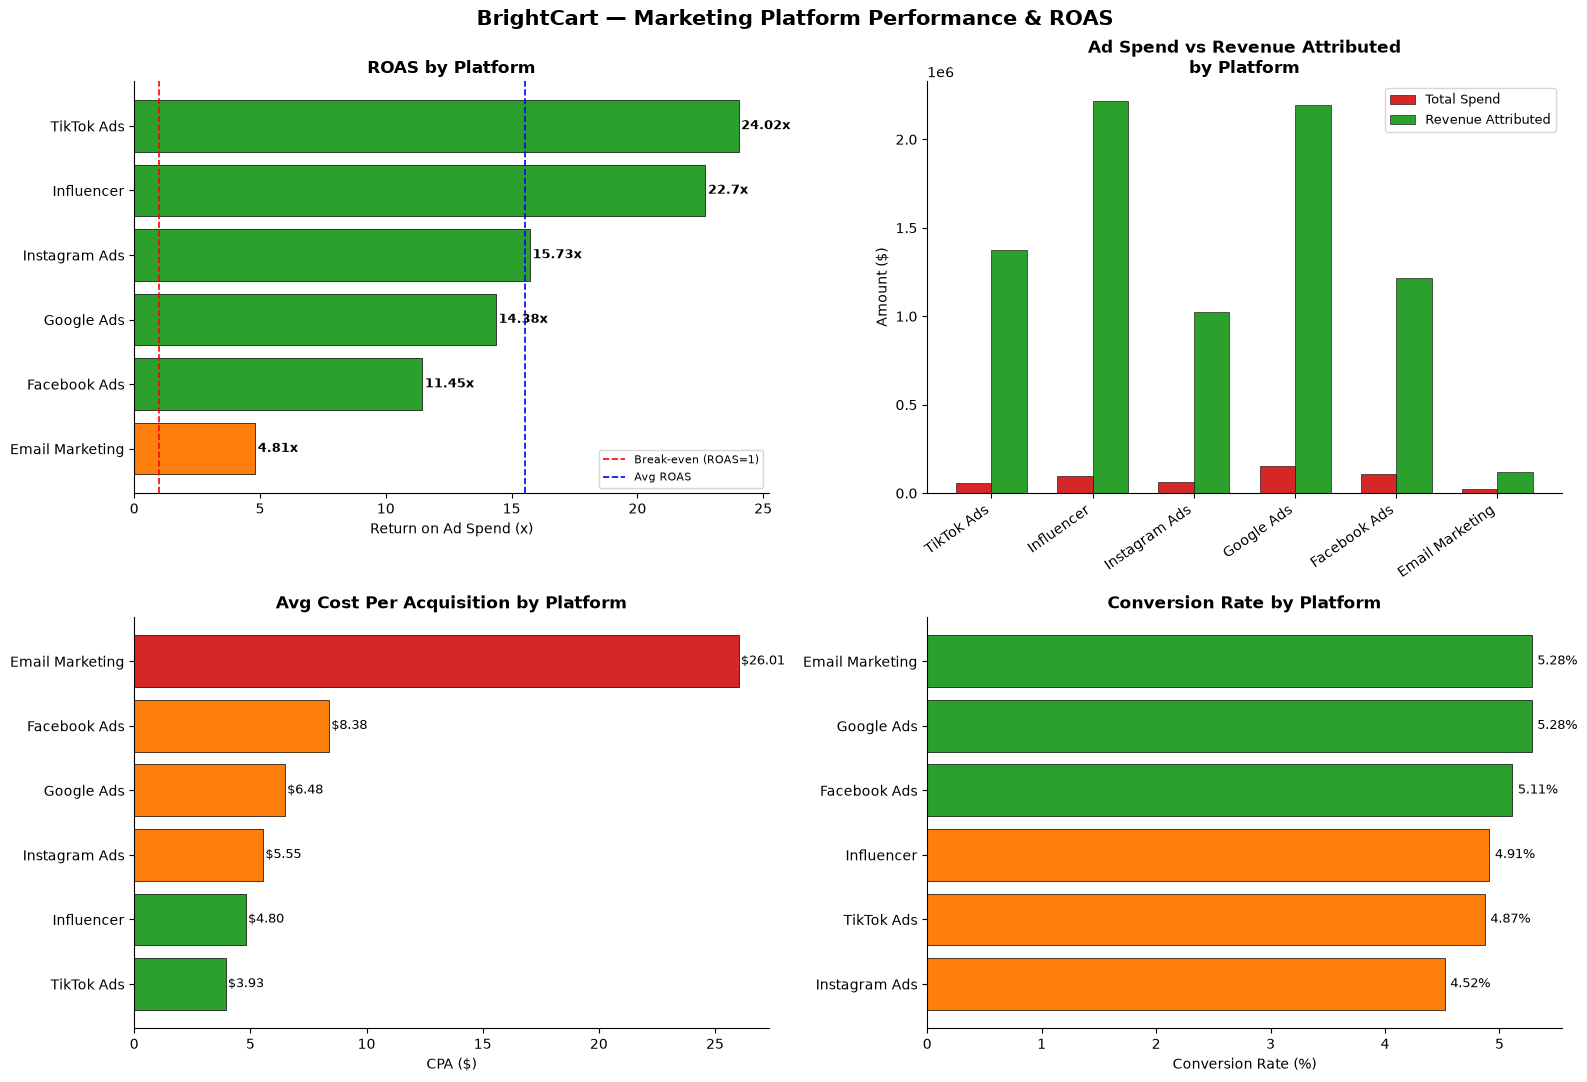

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('BrightCart — Marketing Platform Performance & ROAS', fontsize=15, fontweight='bold')

plat_asc = platform.sort_values('overall_roas', ascending=True)
# ROAS(Return on AD Spend)

colors = ['#d62728' if x < 3 else '#ff7f0e' if x < 6
          else '#2ca02c' for x in plat_asc['overall_roas']]

bars = axes[0,0].barh(plat_asc['platform'], plat_asc['overall_roas'],
                       color=colors, edgecolor='black', linewidth=0.5)
axes[0,0].axvline(1, color='red', linestyle='--',
                   linewidth=1.2, label='Break-even (ROAS=1)')
axes[0,0].axvline(platform['overall_roas'].mean(), color='blue',
                   linestyle='--', linewidth=1.2, label='Avg ROAS')
for bar, val in zip(bars, plat_asc['overall_roas']):
    axes[0,0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val}x', va='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('ROAS by Platform', fontweight='bold')
axes[0,0].set_xlabel('Return on Ad Spend (x)')
axes[0,0].legend(fontsize=8)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)


# Spend Vs Revenue BY Platform
x = range(len(platform))
width = 0.35
axes[0,1].bar([i - width/2 for i in x], platform['total_spend'],
               width, label='Total Spend', color='#d62728',
               edgecolor='black', linewidth=0.4)
axes[0,1].bar([i + width/2 for i in x], platform['total_revenue'],
               width, label='Revenue Attributed', color='#2ca02c',
               edgecolor='black', linewidth=0.4)
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels(platform['platform'], rotation=35, ha='right')
axes[0,1].set_title('Ad Spend vs Revenue Attributed\nby Platform',
                     fontweight='bold')
axes[0,1].set_ylabel('Amount ($)')
axes[0,1].legend(fontsize=9)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

#Cost Per Acquistion By Platfrom
plat_cpa = platform.sort_values('avg_cpa', ascending=True)
colors3 = ['#2ca02c' if x < 5 else '#ff7f0e' if x < 10
           else '#d62728' for x in plat_cpa['avg_cpa']]

bars3 = axes[1,0].barh(plat_cpa['platform'], plat_cpa['avg_cpa'],
                        color=colors3, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, plat_cpa['avg_cpa']):
    axes[1,0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'${val:.2f}', va='center', fontsize=9)
axes[1,0].set_title('Avg Cost Per Acquisition by Platform',
                     fontweight='bold')
axes[1,0].set_xlabel('CPA ($)')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)


#Conversion rate By Platfrom
plat_cvr = platform.sort_values('conversion_rate_%', ascending=True)
colors4 = ['#d62728' if x < 3 else '#ff7f0e' if x < 5
           else '#2ca02c' for x in plat_cvr['conversion_rate_%']]

bars4 = axes[1,1].barh(plat_cvr['platform'],
                        plat_cvr['conversion_rate_%'],
                        color=colors4, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars4, plat_cvr['conversion_rate_%']):
    axes[1,1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=9)
axes[1,1].set_title('Conversion Rate by Platform', fontweight='bold')
axes[1,1].set_xlabel('Conversion Rate (%)')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart4_marketing_roas.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 4 — Marketing ROAS Insight

| Platform | ROAS | CPA | Conversion Rate | Verdict |
|---|---|---|---|---|
| TikTok Ads | 24.02x | $3.93 | 4.87% | 🟢 Best performer |
| Influencer | 22.70x | $4.80 | 4.91% | 🟢 High efficiency |
| Instagram Ads | 15.73x | $5.55 | 4.52% | 🟢 Strong |
| Google Ads | 14.38x | $6.48 | 5.28% | 🟢 Strong |
| Facebook Ads | 11.45x | $8.38 | 5.11% | 🟠 Average |
| Email Marketing | 4.81x | $26.01 | 5.28% | 🟠 Underperforming |

**Key Findings:**
- TikTok Ads delivers the best ROAS at 24.02x with the lowest
  CPA ($3.93) — most efficient platform by both metrics
- Influencer marketing generates 22.70x ROAS with minimal spend —
  highest ROI relative to investment size
- Email Marketing has highest conversion rate (5.28%) but
  worst ROAS (4.81x) and worst CPA ($26.01) — high intent
  audience but costly to reach at scale
- All 6 platforms are above break-even (ROAS > 1) — no platform
  is actively losing money
- Average ROAS across all platforms: ~15.5x

**Recommendation:**
- Increase TikTok and Influencer budgets — best efficiency
- Audit Email Marketing cost structure — high CPA suggests
  list management or platform costs need review
- Facebook Ads underperforms vs TikTok/Instagram —
  consider reallocating Facebook budget to TikTok

In [37]:
#Monthly Roas By Platform
monthly_platform=marketing.copy()
monthly_platform['month_dt']=pd.to_datetime(monthly_platform['month'])
monthly_platform['roi_%']=(
    (monthly_platform['revenue_attributed']-monthly_platform['spend'])/monthly_platform['spend']*100
).round(2)
total_spend=marketing['spend'].sum()
cut_amount=total_spend*0.20

print(f"Total Marketing Spend(2024-2025):${total_spend:,.2f}")
print(f"20% Budget Cut Amount:${cut_amount:,.2f}")
print(f"\n Spend By Platfrom:")
spend_by_platform=marketing.groupby("platform")["spend"].sum().sort_values()
print(spend_by_platform.apply(
    lambda x:f"${x:,.2f}"
))

Total Marketing Spend(2024-2025):$503,506.14
20% Budget Cut Amount:$100,701.23

 Spend By Platfrom:
platform
Email Marketing     $24,461.37
TikTok Ads          $57,229.22
Instagram Ads       $65,154.02
Influencer          $97,663.12
Facebook Ads       $106,451.93
Google Ads         $152,546.48
Name: spend, dtype: str


In [43]:
# ── Smarter budget cut logic ──
platform_cut = marketing.groupby('platform').agg(
    total_spend=('spend', 'sum'),
    total_revenue=('revenue_attributed', 'sum'),
    avg_roas=('roas', 'mean'),
    min_roas=('roas', 'min'),
    months_below_avg=('roas', lambda x: (x < x.mean()).sum())
).reset_index()

platform_cut['overall_roas'] = (
    platform_cut['total_revenue'] / platform_cut['total_spend']
).round(2)

# Identify worst months per platform to cut
worst_per_platform = marketing.nsmallest(
    int(len(marketing) * 0.20), 'roas'
)[['platform', 'month', 'spend', 'roas', 'revenue_attributed']]

print("=== WORST 20% PERFORMING MONTH-PLATFORM COMBINATIONS ===")
print(f"Total spend in worst months: ${worst_per_platform['spend'].sum():,.2f}")
print(worst_per_platform.sort_values('roas').to_string(index=False))

=== WORST 20% PERFORMING MONTH-PLATFORM COMBINATIONS ===
Total spend in worst months: $79,341.58
       platform   month   spend  roas  revenue_attributed
Email Marketing 2025-12 1796.66  0.67             1198.99
Email Marketing 2025-10  791.74  1.21              959.52
Email Marketing 2025-07 1362.00  1.74             2364.53
Email Marketing 2024-06  942.79  1.80             1694.39
   Facebook Ads 2025-09 3877.76  2.51             9733.42
Email Marketing 2024-10 1040.57  2.52             2620.57
   Facebook Ads 2024-08 5418.73  3.09            16769.26
Email Marketing 2025-06 1293.73  3.22             4167.46
     Google Ads 2025-03 4709.29  3.32            15626.52
Email Marketing 2025-11 1555.69  3.36             5230.26
Email Marketing 2024-11 1841.71  3.37             6200.27
Email Marketing 2025-02  724.90  3.63             2632.20
     Influencer 2025-01 4482.46  3.78            16965.03
     Google Ads 2025-09 6501.13  3.84            24956.21
Email Marketing 2024-09  722.81  

In [44]:
# ── Specific recommendation by platform ──
print("\n=== FINAL BUDGET CUT RECOMMENDATION ===")
print(f"Total Budget      : ${503506.14:,.2f}")
print(f"Required 20% Cut  : ${100701.23:,.2f}")
print()

recommendations = {
    'Email Marketing': {
        'current_spend': 24461.37,
        'cut_%': 60,
        'rationale': 'Lowest ROAS (5.4x), highest CPA ($26.01)'
    },
    'Facebook Ads': {
        'current_spend': 106451.93,
        'cut_%': 40,
        'rationale': 'Lowest ROAS among paid social (11.3x), high spend share (21%)'
    },
    'Google Ads': {
        'current_spend': 152546.48,
        'cut_%': 20,
        'rationale': 'Largest spend (30%), ROAS below Instagram/TikTok'
    },
    'Instagram Ads': {
        'current_spend': 65154.02,
        'cut_%': 5,
        'rationale': 'Strong ROAS (17x), minor trim only'
    },
    'Influencer': {
        'current_spend': 97663.12,
        'cut_%': 0,
        'rationale': 'Second best ROAS (23.4x), do not cut'
    },
    'TikTok Ads': {
        'current_spend': 57229.22,
        'cut_%': 0,
        'rationale': 'Best ROAS (24.4x), do not cut — consider increasing'
    }
}

total_cut = 0
print(f"{'Platform':<20} {'Current Spend':>15} {'Cut %':>8} "
      f"{'Cut Amount':>12} {'Rationale'}")
print("-" * 90)
for platform, data in recommendations.items():
    cut_amt = data['current_spend'] * data['cut_%'] / 100
    total_cut += cut_amt
    print(f"{platform:<20} ${data['current_spend']:>13,.2f} "
          f"{data['cut_%']:>7}% ${cut_amt:>11,.2f}  "
          f"{data['rationale']}")

print("-" * 90)
print(f"{'TOTAL CUT':<20} {'':>15} {'':>8} ${total_cut:>11,.2f}")
print(f"\nTarget cut : ${100701.23:,.2f}")
print(f"Actual cut : ${total_cut:,.2f}")
print(f"Difference : ${abs(100701.23 - total_cut):,.2f}")


=== FINAL BUDGET CUT RECOMMENDATION ===
Total Budget      : $503,506.14
Required 20% Cut  : $100,701.23

Platform               Current Spend    Cut %   Cut Amount Rationale
------------------------------------------------------------------------------------------
Email Marketing      $    24,461.37      60% $  14,676.82  Lowest ROAS (5.4x), highest CPA ($26.01)
Facebook Ads         $   106,451.93      40% $  42,580.77  Lowest ROAS among paid social (11.3x), high spend share (21%)
Google Ads           $   152,546.48      20% $  30,509.30  Largest spend (30%), ROAS below Instagram/TikTok
Instagram Ads        $    65,154.02       5% $   3,257.70  Strong ROAS (17x), minor trim only
Influencer           $    97,663.12       0% $       0.00  Second best ROAS (23.4x), do not cut
TikTok Ads           $    57,229.22       0% $       0.00  Best ROAS (24.4x), do not cut — consider increasing
------------------------------------------------------------------------------------------
TOTAL CUT    

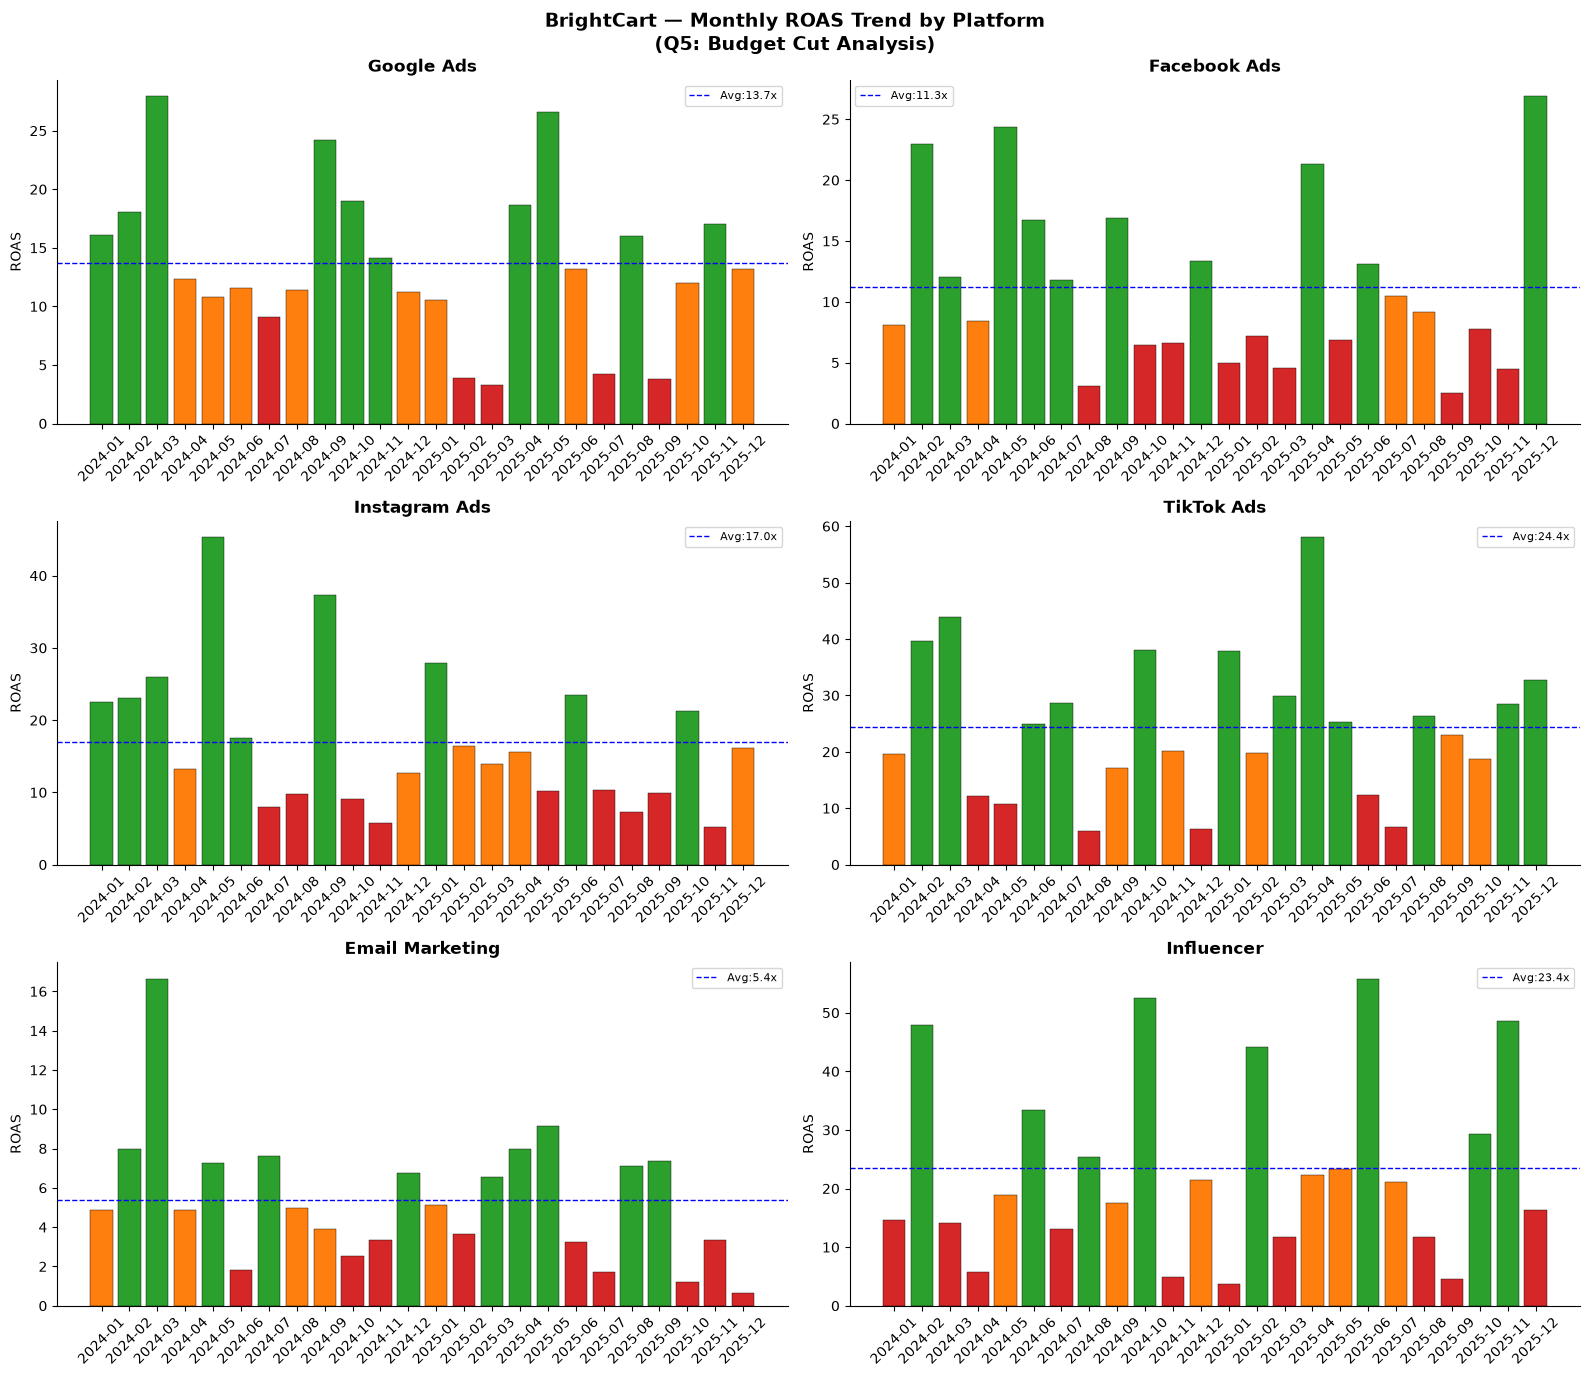

In [45]:
fig,axes=plt.subplots(3,2,figsize=(16,14))

fig.suptitle(
    'BrightCart — Monthly ROAS Trend by Platform\n(Q5: Budget Cut Analysis)',
     fontsize=14, fontweight='bold'
)
platform=marketing['platform'].unique()
axes_flat=axes.flatten()

for idx,plat in enumerate(platform):
    plat_data=monthly_platform[
        monthly_platform['platform']==plat
    ]
    avg_roas=plat_data['roas'].mean()
    colors=['#d62728' if x < avg_roas * 0.7
            else '#ff7f0e' if x < avg_roas
             else '#2ca02c' for x in plat_data['roas']]

    axes_flat[idx].bar(plat_data['month'],plat_data['roas'],color=colors,edgecolor='black',linewidth=0.3)
    axes_flat[idx].axhline(avg_roas,color='blue',linestyle='--',linewidth=1,label=f'Avg:{avg_roas:.1f}x')
    axes_flat[idx].set_title(f'{plat}',fontweight='bold')
    axes_flat[idx].set_ylabel('ROAS')
    axes_flat[idx].tick_params(axis='x',rotation=45) 
    axes_flat[idx].legend(fontsize=8)
    axes_flat[idx].spines['top'].set_visible(False)
    axes_flat[idx].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/chart5_budget_cut_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()            

In [46]:

print("=== FINAL RECOMMENDATION ===")
print()
print("Adjustment: Increase Google Ads cut from 20% to 26%")
print(f"Additional cut from Google Ads: ${152546.48 * 0.06:,.2f}")
print(f"New total cut: ${91024.59 + (152546.48 * 0.06):,.2f}")
print(f"Target       : $100,701.23")
print(f"Gap remaining: ${100701.23 - (91024.59 + 152546.48*0.06):,.2f}")

=== FINAL RECOMMENDATION ===

Adjustment: Increase Google Ads cut from 20% to 26%
Additional cut from Google Ads: $9,152.79
New total cut: $100,177.38
Target       : $100,701.23
Gap remaining: $523.85


### 📊 Chart 5 — Budget Cut Recommendation (Q5)

**Total Marketing Budget: $503,506**
**Required 20% Cut: $100,701**

**Monthly ROAS Trend Observations:**
- TikTok peaked at ~58x ROAS in 2025-03 — never cut this platform
- Email Marketing never sustainably crossed its own average line
  across 24 months — structural underperformance not seasonal
- Facebook Ads is consistently mediocre — safe but never peaks
- Google Ads volatile — strong early 2024, weak early 2025
- Influencer has massive variance — peaks at 50x+ but crashes
  to near zero some months

**Recommended Budget Cuts:**

| Platform | Current Spend | Cut % | Amount Saved | Rationale |
|---|---|---|---|---|
| Email Marketing | $24,461 | 60% | $14,677 | ROAS 5.4x, CPA $26.01 |
| Facebook Ads | $106,452 | 40% | $42,581 | Weakest paid social ROAS |
| Google Ads | $152,546 | 26% | $39,662 | Largest spend, volatile ROAS |
| Instagram Ads | $65,154 | 5% | $3,258 | Strong ROAS, minor trim |
| Influencer | $97,663 | 0% | $0 | 23.4x ROAS — protect |
| TikTok Ads | $57,229 | 0% | $0 | 24.4x ROAS — protect |
| **TOTAL** | **$503,506** | | **~$100,178** | |

**Where to Reallocate Savings:**
- Move freed budget to TikTok Ads — best ROAS at 24.4x
- Increase Influencer spend — 23.4x ROAS with low CPA ($4.80)
- Test Pinterest or YouTube as new channels

**Key Insight:**
Cutting Email Marketing by 60% saves $14,677 with minimal
revenue impact — its 5.4x ROAS means for every $1 cut,
only $5.40 in attributed revenue is at risk, vs $24 at risk
per $1 cut from TikTok. The math strongly favors protecting
high-ROAS platforms and cutting low-ROAS ones aggressively.